In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import datetime
import gc


In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import RNN_preprocessing_sep_chain as rp 

In [4]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649203712, available=368766976, percent=97.8, used=15747420160, free=172466176, active=361517056, inactive=15625105408, buffers=24141824, cached=705175552, shared=162283520, slab=309239808)


In [5]:
import gc
gc.collect()

20

In [6]:
X1_seq_train = rp.X1_seq_train
X1_seq_test = rp.X1_seq_test
y1_seq_train = rp.y1_seq_train
y1_seq_test = rp.y1_seq_test
X2_seq_train = rp.X2_seq_train
X2_seq_test = rp.X2_seq_test
y2_seq_train = rp.y2_seq_train
y2_seq_test = rp.y2_seq_test

In [7]:
X1_seq_train, X1_seq_val, y1_seq_train, y1_seq_val = train_test_split(X1_seq_train, y1_seq_train, test_size=0.2, random_state=0)

In [8]:
X2_seq_train, X2_seq_val, y2_seq_train, y2_seq_val = train_test_split(X2_seq_train, y2_seq_train, test_size=0.2, random_state=0)

In [9]:
# Clear memory associated with the module
del rp
if 'RNN_preprocessing_sep_chain' in sys.modules:
    del sys.modules['RNN_preprocessing_sep_chain']

# Clear memory from global variables if needed
gc.collect()

5

# LSTM

In [10]:
#LSTM model
def model_lstm (input_shape, output_shape):
    model = keras.Sequential(
        [
            layers.LSTM(64, input_shape=input_shape, activation="tanh", return_sequences=True),
            layers.LSTM(32, activation="tanh", return_sequences=True),
            layers.Dense(16, activation="relu"),
            layers.Dense(output_shape, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    return model

In [11]:
seq_length = 10

In [12]:
#Model for the BiPo 214 chain
model1 = model_lstm((seq_length, X1_seq_train.shape[2]), y1_seq_train.shape[2])
model1.summary()

2025-04-08 11:32:50.127344: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            18176     
                                                                 
 lstm_1 (LSTM)               (None, 10, 32)            12416     
                                                                 
 dense (Dense)               (None, 10, 16)            528       
                                                                 
 dense_1 (Dense)             (None, 10, 4)             68        
                                                                 
Total params: 31188 (121.83 KB)
Trainable params: 31188 (121.83 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
#Model for the BiPo 212 chain
model2 = model_lstm((seq_length, X2_seq_train.shape[2]), y2_seq_train.shape[2])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 10, 64)            18176     
                                                                 
 lstm_3 (LSTM)               (None, 10, 32)            12416     
                                                                 
 dense_2 (Dense)             (None, 10, 16)            528       
                                                                 
 dense_3 (Dense)             (None, 10, 6)             102       
                                                                 
Total params: 31222 (121.96 KB)
Trainable params: 31222 (121.96 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [15]:
from keras import backend as K

# Clear any previous session and free memory
tf.keras.backend.clear_session()
K.clear_session()
gc.collect()


12685

In [16]:
# Train model 1
history1 = model1.fit(X1_seq_train, y1_seq_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X1_seq_val, y1_seq_val),
                      callbacks=callbacks)

Epoch 1/200
10805/10805 - 549s - loss: 0.4999 - accuracy: 0.7860 - val_loss: 0.4386 - val_accuracy: 0.8129 - lr: 0.0010 - 549s/epoch - 51ms/step
Epoch 2/200
10805/10805 - 473s - loss: 0.4348 - accuracy: 0.8146 - val_loss: 0.4252 - val_accuracy: 0.8188 - lr: 0.0010 - 473s/epoch - 44ms/step
Epoch 3/200
10805/10805 - 378s - loss: 0.4268 - accuracy: 0.8177 - val_loss: 0.4247 - val_accuracy: 0.8194 - lr: 0.0010 - 378s/epoch - 35ms/step
Epoch 4/200
10805/10805 - 379s - loss: 0.4235 - accuracy: 0.8191 - val_loss: 0.4200 - val_accuracy: 0.8208 - lr: 0.0010 - 379s/epoch - 35ms/step
Epoch 5/200
10805/10805 - 379s - loss: 0.4219 - accuracy: 0.8198 - val_loss: 0.4233 - val_accuracy: 0.8191 - lr: 0.0010 - 379s/epoch - 35ms/step
Epoch 6/200
10805/10805 - 378s - loss: 0.4210 - accuracy: 0.8202 - val_loss: 0.4189 - val_accuracy: 0.8212 - lr: 0.0010 - 378s/epoch - 35ms/step
Epoch 7/200
10805/10805 - 378s - loss: 0.4203 - accuracy: 0.8204 - val_loss: 0.4222 - val_accuracy: 0.8199 - lr: 0.0010 - 378s/epo

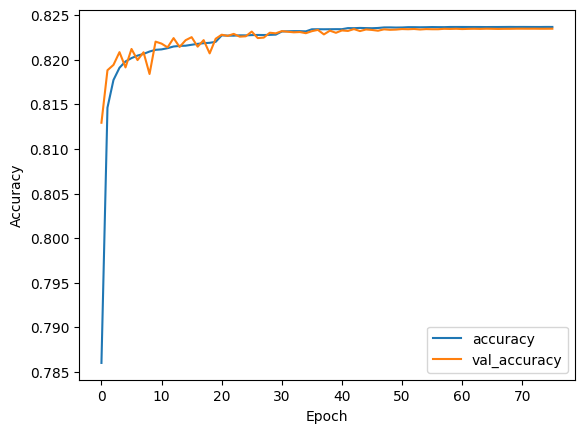

In [17]:
#plotting the accuracy of the first model
import matplotlib.pyplot as plt
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

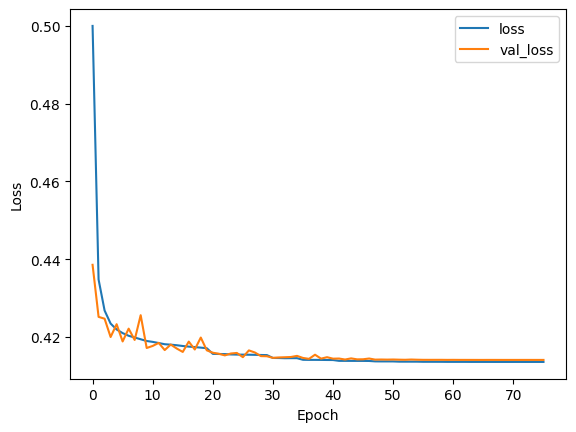

In [18]:
#plotting the loss over epoch for the first model
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [19]:
#save the first trained model
model1.save('../models/model_LSTM_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
# Train model 2
history2 = model2.fit(X2_seq_train, y2_seq_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X2_seq_val, y2_seq_val),
                      callbacks=callbacks)

Epoch 1/200
10693/10693 - 381s - loss: 0.5235 - accuracy: 0.7865 - val_loss: 0.4233 - val_accuracy: 0.8271 - lr: 0.0010 - 381s/epoch - 36ms/step
Epoch 2/200
10693/10693 - 376s - loss: 0.4227 - accuracy: 0.8271 - val_loss: 0.4128 - val_accuracy: 0.8301 - lr: 0.0010 - 376s/epoch - 35ms/step
Epoch 3/200
10693/10693 - 377s - loss: 0.4133 - accuracy: 0.8301 - val_loss: 0.4117 - val_accuracy: 0.8300 - lr: 0.0010 - 377s/epoch - 35ms/step
Epoch 4/200
10693/10693 - 377s - loss: 0.4104 - accuracy: 0.8310 - val_loss: 0.4103 - val_accuracy: 0.8314 - lr: 0.0010 - 377s/epoch - 35ms/step
Epoch 5/200
10693/10693 - 377s - loss: 0.4091 - accuracy: 0.8315 - val_loss: 0.4069 - val_accuracy: 0.8319 - lr: 0.0010 - 377s/epoch - 35ms/step
Epoch 6/200
10693/10693 - 377s - loss: 0.4070 - accuracy: 0.8323 - val_loss: 0.4070 - val_accuracy: 0.8329 - lr: 0.0010 - 377s/epoch - 35ms/step
Epoch 7/200
10693/10693 - 377s - loss: 0.4062 - accuracy: 0.8325 - val_loss: 0.4053 - val_accuracy: 0.8327 - lr: 0.0010 - 377s/epo

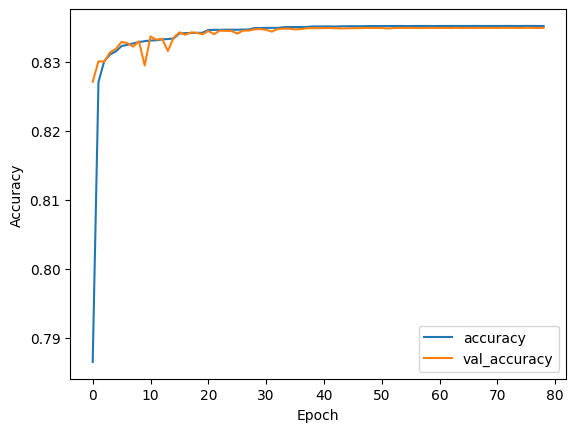

In [21]:
#plotting the accuracy of the second model
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

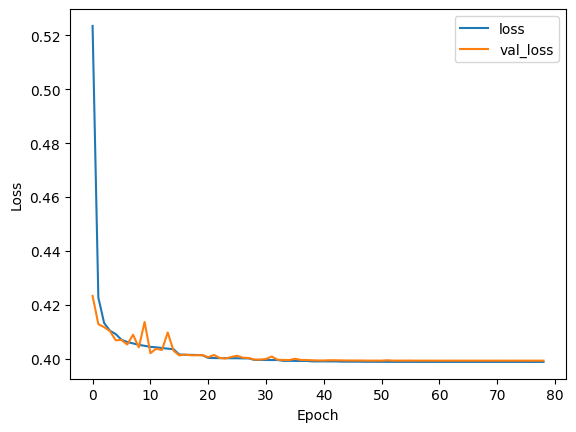

In [22]:
#plotting the loss over epoch for the second model
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [23]:
#save the second trained model
model2.save('../models/model_LSTM_212.h5')